In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holoviews as hv
from IPython.display import display, HTML
%matplotlib inline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import optuna

In [127]:
FILE_PATH = './bike_output.csv'

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
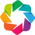

In [129]:
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))
pd.set_option('display.max_rows', 250)
pd.set_option('display.max_columns', 250)
hv.extension('bokeh')

In [131]:
df_bike_model = pd.read_csv(FILE_PATH)
df_bike_model['dteday'] = pd.to_datetime(df_bike_model['dteday'])
df_bike_model.sort_values('dteday', inplace=True)

In [133]:
# New variables using weather
df_bike_model['wind_hum'] = df_bike_model['windspeed'] * df_bike_model['hum']
df_bike_model['atemp_lag2'] = df_bike_model['atemp'].shift(2)
df_bike_model['hum_lag2'] = df_bike_model['hum'].shift(2)
df_bike_model['atemp_hum'] = df_bike_model['atemp'] * df_bike_model['hum']
df_bike_model['atemp_wind'] = df_bike_model['atemp'] * df_bike_model['windspeed']

# new variables with time lag so we only use available data at the time of prediction - no leakage
df_bike_model['cnt_lag2'] = df_bike_model['cnt'].shift(2) 
df_bike_model['cnt_lag7'] = df_bike_model['cnt'].shift(7)

# --- Add Cyclical Encoding for Monthly Cycles ---
df_bike_model['mnth_sin'] = np.sin(2 * np.pi * df_bike_model['mnth'] / 12)
df_bike_model['mnth_cos'] = np.cos(2 * np.pi * df_bike_model['mnth'] / 12)

# --- Add Cyclical Encoding for Seasonal Cycles ---
df_bike_model['season_sin'] = np.sin(2 * np.pi * df_bike_model['season'] / 4)
df_bike_model['season_cos'] = np.sin(2 * np.pi * df_bike_model['season'] / 4)

In [139]:
df_bike_model.isna().count()

Unnamed: 0    731
dteday        731
season        731
yr            731
mnth          731
holiday       731
weekday       731
workingday    731
weathersit    731
atemp         731
hum           731
windspeed     731
cnt           731
wind_hum      731
atemp_lag2    731
hum_lag2      731
atemp_hum     731
atemp_wind    731
cnt_lag2      731
cnt_lag7      731
mnth_sin      731
mnth_cos      731
season_sin    731
season_cos    731
dtype: int64

In [141]:
# split the dataset into one dataset for train and one for test
df_seen, df_unseen = train_test_split(df_bike_model, test_size=0.2, random_state=42, shuffle=False)

In [143]:
df_seen.head()

,Unnamed: 0,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt,wind_hum,atemp_lag2,hum_lag2,atemp_hum,atemp_wind,cnt_lag2,cnt_lag7,mnth_sin,mnth_cos,season_sin,season_cos
0,0,2011-01-01,1,0,1,0,6.0,0,2,0.363625,0.805833,0.160446,985,0.129293,NaN,NaN,0.293021,0.058342,NaN,NaN,0.5,0.866025,1.0,1.0
1,1,2011-01-02,1,0,1,0,0.0,0,2,0.353739,0.696087,0.248539,801,0.173005,NaN,NaN,0.246233,0.087918,NaN,NaN,0.5,0.866025,1.0,1.0
2,2,2011-01-03,1,0,1,0,1.0,1,1,0.189405,0.437273,0.248309,1349,0.108579,0.363625,0.805833,0.082822,0.047031,985.0,NaN,0.5,0.866025,1.0,1.0
3,3,2011-01-04,1,0,1,0,2.0,1,1,0.212122,0.590435,0.160296,1562,0.094644,0.353739,0.696087,0.125244,0.034002,801.0,NaN,0.5,0.866025,1.0,1.0
4,4,2011-01-05,1,0,1,0,3.0,1,1,0.229270,0.436957,0.186900,1600,0.081667,0.189405,0.437273,0.100181,0.042851,1349.0,NaN,0.5,0.866025,1.0,1.0


In [145]:
# find nan in the train dataset
df_seen.isna().sum()

Unnamed: 0    0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       2
workingday    0
weathersit    0
atemp         0
hum           0
windspeed     0
cnt           0
wind_hum      0
atemp_lag2    2
hum_lag2      2
atemp_hum     0
atemp_wind    0
cnt_lag2      2
cnt_lag7      7
mnth_sin      0
mnth_cos      0
season_sin    0
season_cos    0
dtype: int64

In [147]:
#fill out nan with median
df_seen.fillna(df_seen.median(), inplace=True)

In [149]:
# check for nan in test dataset
df_unseen.isna().sum()

Unnamed: 0    0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
atemp         0
hum           0
windspeed     0
cnt           0
wind_hum      0
atemp_lag2    0
hum_lag2      0
atemp_hum     0
atemp_wind    0
cnt_lag2      0
cnt_lag7      0
mnth_sin      0
mnth_cos      0
season_sin    0
season_cos    0
dtype: int64

In [151]:
# define target variables in both datasets
X_train = df_seen.drop(columns=['Unnamed: 0', 'cnt', 'dteday', 'mnth', 'season'])
y_train = df_seen['cnt']

X_test = df_unseen.drop(columns=['Unnamed: 0', 'cnt', 'dteday', 'mnth', 'season'])
y_test = df_unseen['cnt']

In [153]:
X_train.head()

,yr,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,wind_hum,atemp_lag2,hum_lag2,atemp_hum,atemp_wind,cnt_lag2,cnt_lag7,mnth_sin,mnth_cos,season_sin,season_cos
0,0,0,6.0,0,2,0.363625,0.805833,0.160446,0.129293,0.489690,0.621667,0.293021,0.058342,4195.0,4189.0,0.5,0.866025,1.0,1.0
1,0,0,0.0,0,2,0.353739,0.696087,0.248539,0.173005,0.489690,0.621667,0.246233,0.087918,4195.0,4189.0,0.5,0.866025,1.0,1.0
2,0,0,1.0,1,1,0.189405,0.437273,0.248309,0.108579,0.363625,0.805833,0.082822,0.047031,985.0,4189.0,0.5,0.866025,1.0,1.0
3,0,0,2.0,1,1,0.212122,0.590435,0.160296,0.094644,0.353739,0.696087,0.125244,0.034002,801.0,4189.0,0.5,0.866025,1.0,1.0
4,0,0,3.0,1,1,0.229270,0.436957,0.186900,0.081667,0.189405,0.437273,0.100181,0.042851,1349.0,4189.0,0.5,0.866025,1.0,1.0


In [155]:
#confirm that there are no nan in the train dataset
X_train.isna().sum()

yr            0
holiday       0
weekday       0
workingday    0
weathersit    0
atemp         0
hum           0
windspeed     0
wind_hum      0
atemp_lag2    0
hum_lag2      0
atemp_hum     0
atemp_wind    0
cnt_lag2      0
cnt_lag7      0
mnth_sin      0
mnth_cos      0
season_sin    0
season_cos    0
dtype: int64

In [157]:
y_train.isna().count()

584

In [159]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 0 to 583
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   yr          584 non-null    int64  
 1   holiday     584 non-null    int64  
 2   weekday     584 non-null    float64
 3   workingday  584 non-null    int64  
 4   weathersit  584 non-null    int64  
 5   atemp       584 non-null    float64
 6   hum         584 non-null    float64
 7   windspeed   584 non-null    float64
 8   wind_hum    584 non-null    float64
 9   atemp_lag2  584 non-null    float64
 10  hum_lag2    584 non-null    float64
 11  atemp_hum   584 non-null    float64
 12  atemp_wind  584 non-null    float64
 13  cnt_lag2    584 non-null    float64
 14  cnt_lag7    584 non-null    float64
 15  mnth_sin    584 non-null    float64
 16  mnth_cos    584 non-null    float64
 17  season_sin  584 non-null    float64
 18  season_cos  584 non-null    float64
dtypes: float64(15), int64(4)
memory us

In [161]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 584 entries, 0 to 583
Series name: cnt
Non-Null Count  Dtype
--------------  -----
584 non-null    int64
dtypes: int64(1)
memory usage: 9.1 KB


In [306]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 1000)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', [None, 'sqrt', 'log2'])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
                                             

    # define model pipeline
    pipeline = Pipeline([
        ('rf', RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            bootstrap=bootstrap,
            random_state=42))
    ])
    
    #evaluate with cross validation (5 folds)
    scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='r2')
    
    return scores.mean()  

In [ ]:
#create and run the Optuna study, aiming to maximize R^2
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=1000)

[I 2025-04-05 16:58:54,158] A new study created in memory with name: no-name-aa739025-a7ec-488f-994c-36b839f466d5
[I 2025-04-05 16:58:57,205] Trial 0 finished with value: 0.016568430838347137 and parameters: {'n_estimators': 974, 'max_depth': 40, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.016568430838347137.
[I 2025-04-05 16:58:58,079] Trial 1 finished with value: -0.010285621236363193 and parameters: {'n_estimators': 320, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.016568430838347137.
[I 2025-04-05 16:59:00,698] Trial 2 finished with value: -0.05226577727611681 and parameters: {'n_estimators': 460, 'max_depth': 23, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 0 with value: 0.016568430838347137.
[I 2025-04-05 16:59:02,407] Trial 3 finished with value: -0.02662

In [276]:
#display best results
print("Best trial:")
trial=study.best_trial
print(f" Best r2: {trial.value}")
print(" Best hyperparameters:")
for key, value in trial.params.items():
    print(f" {key}: {value}")

Best trial:
 Best r2: -0.0024415277376034217
 Best hyperparameters:
 n_estimators: 62
 max_depth: 27
 min_samples_split: 0.0001356903002777386
 min_samples_leaf: 0.00020777490423959393


/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_66513/1036994904.py:1: ExperimentalWarning:

plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

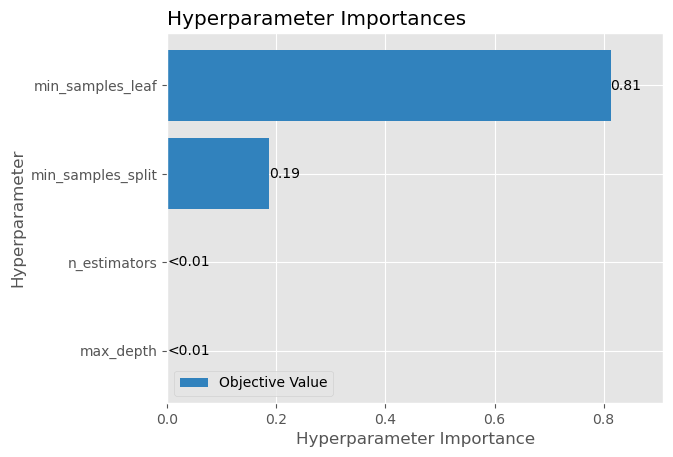

In [278]:
optuna.visualization.matplotlib.plot_param_importances(study)

In [279]:
pipeline = Pipeline([
    ('rf', RandomForestRegressor(random_state=42))
])

# save the best parametes
best_params = study.best_trial.params

#update pipeline
best_pipeline = pipeline.set_params(
    rf__n_estimators=best_params['n_estimators'],
    rf__max_depth=best_params['max_depth'],
    rf__min_samples_split=best_params['min_samples_split'],
    rf__min_samples_leaf=best_params['min_samples_leaf']
)

In [280]:
# apply pipeline to train and target variables
best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('rf',
                 RandomForestRegressor(max_depth=27,
                                       min_samples_leaf=0.00020777490423959393,
                                       min_samples_split=0.0001356903002777386,
                                       n_estimators=62, random_state=42))])

In [281]:
y_train_pred = best_pipeline.predict(X_train)

In [282]:
# find the r2 score when compared with the actual target values
r2_train = r2_score(y_train, y_train_pred)
print(f" R2 of train: {r2_train}")

# find the root squared mean error of the train dataset
rsme_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f" RMSE of train: {rsme_train}")
rsme_train

mae_train = mean_absolute_error(y_train, y_train_pred)
print(f" MAE of train: {mae_train}")

mse_train = mean_squared_error(y_train, y_train_pred)
print(f" MSE of train: {mse_train}")

mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
print(f" MAPE of train: {mape_train}")

 R2 of train: 0.9807097222896606
 RMSE of train: 248.2447893068753
 MAE of train: 174.57108926204157
 MSE of train: 61625.47541801491
 MAPE of train: 0.06586162146073767


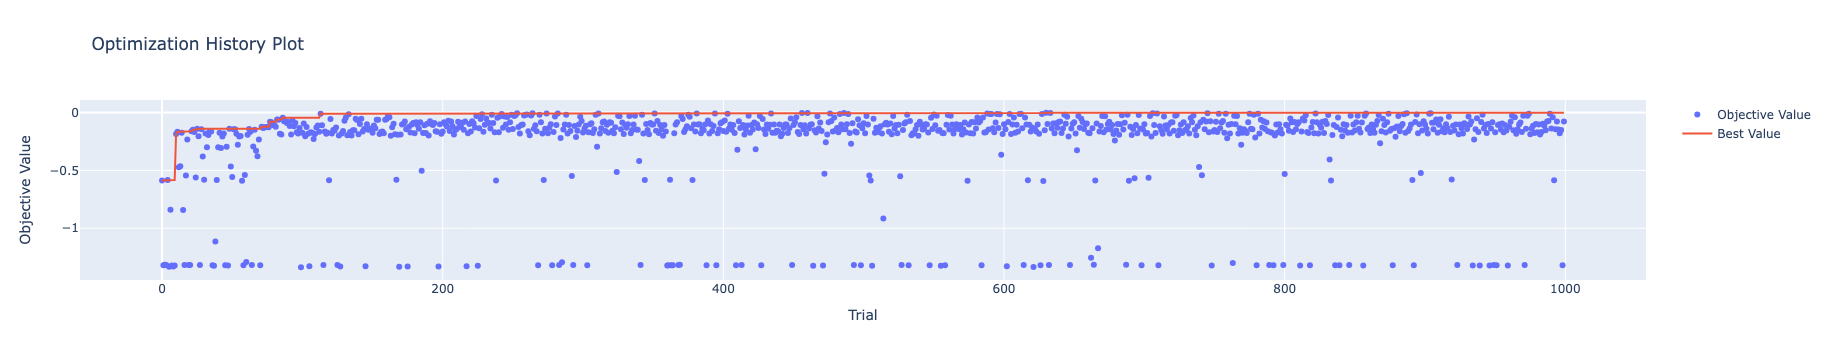

In [283]:
# Optimization history
optuna.visualization.plot_optimization_history(study)

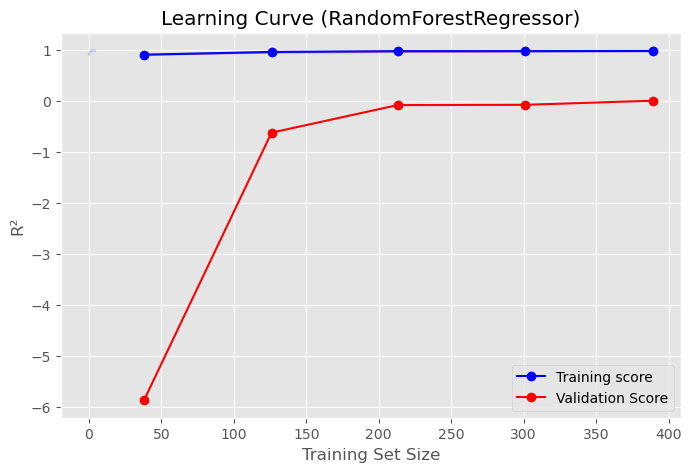

In [284]:
# Plot the learning curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=best_pipeline,
    X=X_train,
    y=y_train,
    cv=3,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42
)

#compute means and std devs for plotting
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std = np.std(valid_scores, axis=1)

#plot
plt.figure(figsize=(8, 5))

plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training score')

plt.plot(train_sizes,
         train_scores_mean - train_scores_std,
         train_scores_mean + train_scores_std,
         alpha=0.2, color='blue')

plt.plot(train_sizes, valid_scores_mean, 'o-', color='red', label='Validation Score')

plt.fill_between(train_sizes,
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.2, color='red')

plt.title('Learning Curve (RandomForestRegressor)')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [285]:
# predic values using the test variables (unseen data)
y_test_pred = best_pipeline.predict(X_test)

In [286]:
# find the r2 score when compared with the actual target values
r2_test = r2_score(y_test, y_test_pred)
print(f" R2 of test: {r2_test}")

# find the root squared mean error of the train dataset
rsme_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f" RMSE of test: {rsme_test}")

mae_test = mean_absolute_error(y_test, y_test_pred)
print(f" MAE of test: {mae_test}")

mse_test = mean_squared_error(y_test, y_test_pred)
print(f" MSE of test: {mse_test}")

mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
print(f" MAPE of test: {mape_test}")

 R2 of test: 0.6432993833695819
 RMSE of test: 1119.6059875146384
 MAE of test: 906.7135176651304
 MSE of test: 1253517.5672786285
 MAPE of test: 1.4276053204183201


In [287]:
# Saving the estimator as model is just for convenience when you need to inspect or use the final estimator directly (for example, to check its coefficients).
model = best_pipeline.named_steps['rf']

In [288]:
# check the coefficients
feature_importance = model.feature_importances_
feature_importance

array([0.17758309, 0.00064968, 0.00759163, 0.00262993, 0.01071042,
       0.42776063, 0.04041437, 0.00786915, 0.03384043, 0.01501072,
       0.01281789, 0.01365244, 0.00885865, 0.17040144, 0.05085406,
       0.00811908, 0.00544153, 0.00293531, 0.00285955])

In [289]:
# retrieve the names of the train features
features = X_train.columns
features

Index(['yr', 'holiday', 'weekday', 'workingday', 'weathersit', 'atemp', 'hum',
       'windspeed', 'wind_hum', 'atemp_lag2', 'hum_lag2', 'atemp_hum',
       'atemp_wind', 'cnt_lag2', 'cnt_lag7', 'mnth_sin', 'mnth_cos',
       'season_sin', 'season_cos'],
      dtype='object')

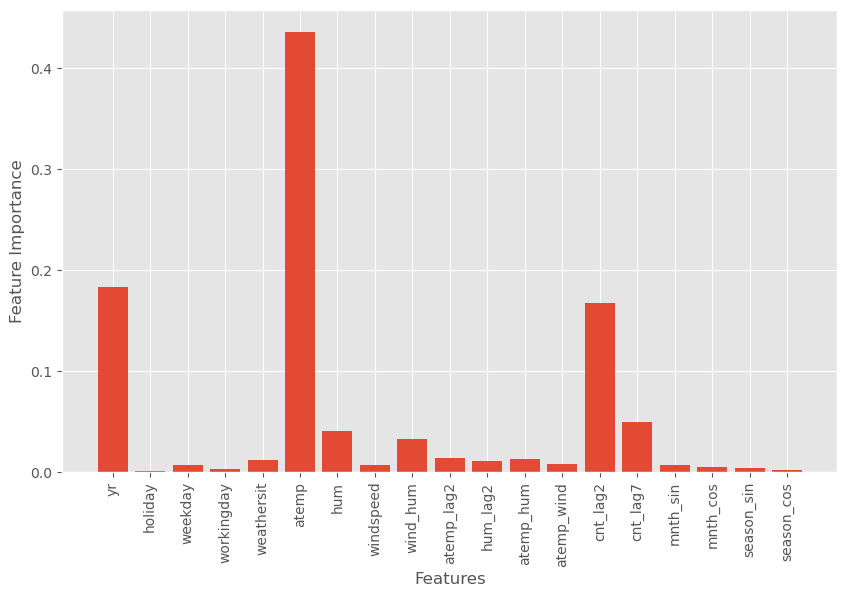

In [268]:
# plot the coefficient (weight) of each feature used to train the model
plt.figure(figsize=(10, 6))
plt.bar(features, feature_importance)
plt.xlabel("Features")
plt.ylabel("Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [270]:
df_unseen['predict'] = y_test_pred

In [272]:
df_unseen['error'] = df_unseen['cnt'] - df_unseen['predict']

<Axes: >

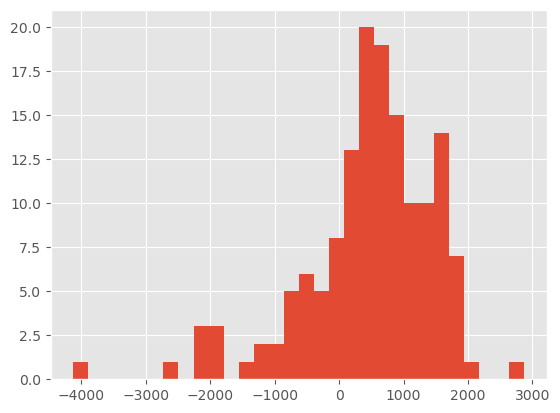

In [274]:
df_unseen['error'].hist(bins=30)